In [1]:
import pandas as pd

In [3]:
ori_data = pd.read_csv("E:\\Python\\e_download_dataset\\二手房数据.csv")
ori_data.head(5)

,市区,小区,户型,朝向,楼层,装修情况,电梯,面积(㎡),价格(万元),年份
0,朝阳,育慧里一区,1室0厅,西,7,精装,有电梯,52,343,2001
1,朝阳,大西洋新城A区,2室2厅,南北,10,精装,有电梯,86,835,1999
2,朝阳,团结湖路,2室1厅,东西,6,精装,无电梯,65,430,1980
3,朝阳,尚家楼48号院,2室1厅,南北,12,精装,有电梯,75,610,1998
4,朝阳,望京西园一区,3室2厅,南北,6,精装,无电梯,115,710,1997


# Project: 二手房数据分析

## Analysis objective

## Introduction

Beijing second-hand housing data, including information on properties across various districts, location specifics, layout types, area, price, and year of construction.

## Evaluate data.

### Evaluate data tidiness.etc

### Evaluate data cleanliness.

#### Evaluate inconsistent data and data type.

In [4]:
ori_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23677 entries, 0 to 23676
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   市区      23677 non-null  object
 1   小区      23677 non-null  object
 2   户型      23677 non-null  object
 3   朝向      23677 non-null  object
 4   楼层      23677 non-null  object
 5   装修情况    23677 non-null  object
 6   电梯      15426 non-null  object
 7   面积(㎡)   23677 non-null  object
 8   价格(万元)  23677 non-null  object
 9   年份      23677 non-null  object
dtypes: object(10)
memory usage: 1.8+ MB


From the output, there are a total of 23677 observations.  
`电梯` have missing values, **we need to handle it later.**

In [5]:
clean_data = ori_data.copy()
clean_data.head(1)

,市区,小区,户型,朝向,楼层,装修情况,电梯,面积(㎡),价格(万元),年份
0,朝阳,育慧里一区,1室0厅,西,7,精装,有电梯,52,343,2001


In [12]:
clean_data[clean_data['电梯'].isna()]

,市区,小区,户型,朝向,楼层,装修情况,电梯,面积(㎡),价格(万元),年份
16,朝阳,兴隆家园,3室1厅,南北,6,精装,NaN,116,696,2000
17,朝阳,北苑家园望春园,2室1厅,南北,14,精装,NaN,108,680,2006
20,朝阳,双龙南里,3室1厅,南北,18,简装,NaN,72,409,1993
22,朝阳,名人公寓,4室2厅,南,17,精装,NaN,379,2000,2002
31,海淀,上林溪,1室0厅,南,11,精装,NaN,44,380,2011
...,...,...,...,...,...,...,...,...,...,...
23650,东城,新景家园东区,1室1厅,南北,15,精装,NaN,81,790,2008
23651,东城,锡拉胡同21号院,3室1厅,东西,6,精装,NaN,75,780,1988
23654,东城,兴隆都市馨园,1室1厅,南,7,精装,NaN,39,420,2004
23667,西城,双旗杆东里,2室1厅,西北,18,简装,NaN,58,610,1986


In [14]:
clean_data['电梯'].value_counts()

有电梯      9339
无电梯      6073
南北          3
3室2厅        2
2室1厅        2
5           1
6房间4卫       1
5室2厅        1
东西          1
西北          1
1室0厅        1
3室1厅        1
Name: 电梯, dtype: int64

In [16]:
# ‘电梯’ == ‘户型’
clean_data[clean_data['电梯'] == '6房间4卫']

,市区,小区,户型,朝向,楼层,装修情况,电梯,面积(㎡),价格(万元),年份
3406,延庆,国锐金嵿,6房间4卫,南北,22,精装,6房间4卫,南北,22,精装


In [17]:
# ‘电梯’ == ‘朝向’
clean_data[clean_data['电梯'] == '东西']

,市区,小区,户型,朝向,楼层,装修情况,电梯,面积(㎡),价格(万元),年份
10779,石景山,苹果园小区一区,3室1厅,东西,苹果园小区一区,3室1厅,东西,6,简装,1985


In [18]:
clean_data[clean_data['电梯'] == clean_data['户型']]

,市区,小区,户型,朝向,楼层,装修情况,电梯,面积(㎡),价格(万元),年份
860,房山,中国铁建原香漫谷,3室2厅,南北,18,毛坯,3室2厅,南北,18,毛坯
3406,延庆,国锐金嵿,6房间4卫,南北,22,精装,6房间4卫,南北,22,精装
4232,大兴,众美城,5室2厅,南北,6,简装,5室2厅,南北,6,简装
6669,昌平,东关南里小区,3室2厅,南北,6,精装,3室2厅,南北,6,精装
11938,丰台,福顺里,2室1厅,西南,20,其他,2室1厅,西南,20,2002
17532,朝阳,团结湖公寓,1室0厅,北,21,精装,1室0厅,北,21,1999
19577,朝阳,金地名京,2室1厅,东西,2室1厅,东西,2室1厅,东西,2室1厅,东西


In [19]:
clean_data[clean_data['电梯'] == '3室1厅']

,市区,小区,户型,朝向,楼层,装修情况,电梯,面积(㎡),价格(万元),年份
23529,东城,金鱼池东区,2室1厅,东西,6,精装,3室1厅,东西,615,2002


There is unrealistic values in the `电梯`.  

Replace both unrealistic values and NaN with '未知'.

In [20]:
# clean_data.fillna()
# 定义电梯列的有效值：只有“有电梯”和“无电梯”
valid_values = ['有电梯', '无电梯']

# 核心：把非有效值（包括NaN）全部替换成“未知”
# 逻辑：如果值在有效值里就保留，否则换成“未知”
clean_data['电梯'] = clean_data['电梯'].where(clean_data['电梯'].isin(valid_values), '未知')
clean_data['电梯'].value_counts()

有电梯    9339
未知     8265
无电梯    6073
Name: 电梯, dtype: int64

#### Evaluate invalid and incorrect data.

In [21]:
clean_data['市区'].value_counts()

海淀     2983
朝阳     2973
丰台     2952
昌平     2811
西城     2130
大兴     2115
通州     1602
东城     1533
房山     1442
顺义     1221
石景山     882
门头沟     496
延庆      469
平谷       41
怀柔       15
密云       12
Name: 市区, dtype: int64

In [22]:
clean_data['小区'].value_counts()

远洋山水         102
荣丰2008        97
首邑溪谷          75
加州水郡三期        63
金隅万科城         61
            ... 
团结湖北头条         1
安苑东里三区         1
北京青年城          1
劲松五区           1
台基厂头条10号院      1
Name: 小区, Length: 4526, dtype: int64

In [23]:
clean_data['户型'].value_counts()

2室1厅      9485
3室1厅      3999
3室2厅      2765
1室1厅      2681
2室2厅      1671
4室2厅       930
1室0厅       499
4室1厅       295
5室2厅       200
2房间1卫      170
1房间1卫      146
3房间1卫      116
4室3厅        96
5室3厅        75
1室2厅        67
6室2厅        59
3房间2卫       53
2室0厅        50
3室3厅        43
4房间2卫       31
3室0厅        29
6室3厅        29
5室1厅        27
叠拼别墅        20
2房间2卫       18
4房间1卫       15
1房间0卫       15
5房间2卫       10
7室3厅         7
4房间3卫        7
5房间3卫        6
7室2厅         6
2室3厅         5
6室4厅         4
8室3厅         4
5室4厅         4
4室4厅         4
4室0厅         3
8室2厅         3
3房间0卫        3
6房间4卫        3
1房间2卫        2
6室0厅         2
3房间3卫        2
2房间0卫        2
6房间3卫        2
9室1厅         1
11房间3卫       1
8室4厅         1
6室1厅         1
9室3厅         1
7房间2卫        1
5房间0卫        1
9室2厅         1
8室5厅         1
5室0厅         1
1室3厅         1
6室5厅         1
6房间5卫        1
7室1厅         1
Name: 户型, dtype: int64

In [25]:
clean_data['朝向'].value_counts()

南北    11433
南      2847
东南     2096
西南     1663
东西     1559
东       934
西       889
西北      781
东北      681
北       612
南西      182
Name: 朝向, dtype: int64

In [26]:
clean_data['装修情况'].value_counts()

精装      11352
简装       8498
其他       3239
毛坯        583
1室1厅        1
南北          1
3室1厅        1
2室1厅        1
东西          1
Name: 装修情况, dtype: int64

In [27]:
valid_values = ['精装', '简装', '其他']
clean_data = clean_data.where(clean_data['装修情况'].isin(valid_values), '未知')
clean_data['装修情况'].value_counts()

精装    11352
简装     8498
其他     3239
未知      588
Name: 装修情况, dtype: int64

In [28]:
clean_data['楼层'].value_counts()

6     7472
18    1514
5     1023
16    1018
24     851
7      801
11     768
15     763
14     731
12     688
9      645
21     634
20     633
未知     588
22     568
28     499
26     451
4      436
10     397
13     390
27     389
17     362
25     353
19     341
8      308
23     252
3      182
29     166
30     123
32      96
2       82
31      64
33      32
34      21
35      17
36       8
1        6
40       3
42       1
57       1
Name: 楼层, dtype: int64

In [30]:
clean_data['面积(㎡)'].value_counts()

未知     588
89     465
58     389
57     382
60     371
      ... 
362      1
301      1
272      1
483      1
东西       1
Name: 面积(㎡), Length: 408, dtype: int64

In [32]:
import numpy as np
clean_data['面积(㎡)'] = clean_data['面积(㎡)'].replace('东西', np.nan)
clean_data['面积(㎡)'].value_counts()

未知       588
89       465
58       389
57       382
60       371
        ... 
325        1
361.8      1
427.5      1
414        1
608        1
Name: 面积(㎡), Length: 407, dtype: int64

In [33]:
clean_data['价格(万元)'].value_counts()

未知       588
450      312
430      299
550      293
350      287
        ... 
1487       1
1005       1
351.7      1
419.8      1
1293       1
Name: 价格(万元), Length: 1331, dtype: int64

In [34]:
clean_data['年份'].value_counts()

2004    1746
2003    1482
2005    1391
2000    1187
2002    1145
        ... 
简装         2
1961       1
无电梯        1
1952       1
1953       1
Name: 年份, Length: 69, dtype: int64

There is invalid values in `年份`, we're not sure if it affect the data analyze, so we can keep it.

In [35]:
clean_data[clean_data['价格(万元)'] == '未知']

,市区,小区,户型,朝向,楼层,装修情况,电梯,面积(㎡),价格(万元),年份
115,未知,未知,未知,未知,未知,未知,未知,未知,未知,未知
145,未知,未知,未知,未知,未知,未知,未知,未知,未知,未知
149,未知,未知,未知,未知,未知,未知,未知,未知,未知,未知
171,未知,未知,未知,未知,未知,未知,未知,未知,未知,未知
182,未知,未知,未知,未知,未知,未知,未知,未知,未知,未知
...,...,...,...,...,...,...,...,...,...,...
23438,未知,未知,未知,未知,未知,未知,未知,未知,未知,未知
23448,未知,未知,未知,未知,未知,未知,未知,未知,未知,未知
23544,未知,未知,未知,未知,未知,未知,未知,未知,未知,未知
23612,未知,未知,未知,未知,未知,未知,未知,未知,未知,未知


In [36]:
clean_data = clean_data[~clean_data.eq('未知').all(axis=1)]
clean_data[clean_data['价格(万元)'] == '未知']

,市区,小区,户型,朝向,楼层,装修情况,电梯,面积(㎡),价格(万元),年份


In [37]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23089 entries, 0 to 23676
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   市区      23089 non-null  object
 1   小区      23089 non-null  object
 2   户型      23089 non-null  object
 3   朝向      23089 non-null  object
 4   楼层      23089 non-null  object
 5   装修情况    23089 non-null  object
 6   电梯      23089 non-null  object
 7   面积(㎡)   23088 non-null  object
 8   价格(万元)  23089 non-null  object
 9   年份      23089 non-null  object
dtypes: object(10)
memory usage: 1.9+ MB


`装修情况`, `电梯` should be 'Category'.  
`面积(㎡)`, `价格(万元)` should be int.  
**We need to convey their type.**

In [48]:
clean_data['装修情况'] = clean_data['装修情况'].astype('category')
clean_data['电梯'] = clean_data['电梯'].astype('category')
# clean_data['面积(㎡)'] = clean_data['面积(㎡)'].astype(float)
# clean_data['价格(万元)'] = clean_data['价格(万元)'].astype(float)
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23089 entries, 0 to 23676
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   市区      23089 non-null  object  
 1   小区      23089 non-null  object  
 2   户型      23089 non-null  object  
 3   朝向      23089 non-null  object  
 4   楼层      23089 non-null  object  
 5   装修情况    23089 non-null  category
 6   电梯      23089 non-null  category
 7   面积(㎡)   23088 non-null  object  
 8   价格(万元)  23089 non-null  object  
 9   年份      23089 non-null  object  
dtypes: category(2), object(8)
memory usage: 1.6+ MB


C:\Users\wangm\AppData\Local\Temp\ipykernel_3068\3311243316.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['装修情况'] = clean_data['装修情况'].astype('category')
C:\Users\wangm\AppData\Local\Temp\ipykernel_3068\3311243316.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['电梯'] = clean_data['电梯'].astype('category')


In [41]:
clean_data['面积(㎡)'].value_counts()

89       465
58       389
57       382
60       371
88       369
        ... 
361.8      1
427.5      1
414        1
337        1
608        1
Name: 面积(㎡), Length: 406, dtype: int64

In [42]:
clean_data['价格(万元)'].value_counts()

450      312
430      299
550      293
350      287
420      283
        ... 
1487       1
1005       1
351.7      1
419.8      1
1293       1
Name: 价格(万元), Length: 1330, dtype: int64

Can't convey 面积(㎡), 价格(万元) to int.

In [49]:
clean_data.head(3)

,市区,小区,户型,朝向,楼层,装修情况,电梯,面积(㎡),价格(万元),年份
0,朝阳,育慧里一区,1室0厅,西,7,精装,有电梯,52,343,2001
1,朝阳,大西洋新城A区,2室2厅,南北,10,精装,有电梯,86,835,1999
2,朝阳,团结湖路,2室1厅,东西,6,精装,无电梯,65,430,1980


## Explore data.

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
plt.rcParams['figure.figsize'] = [70.0, 35.0]
plt.rcParams['figure.autolayout'] = True

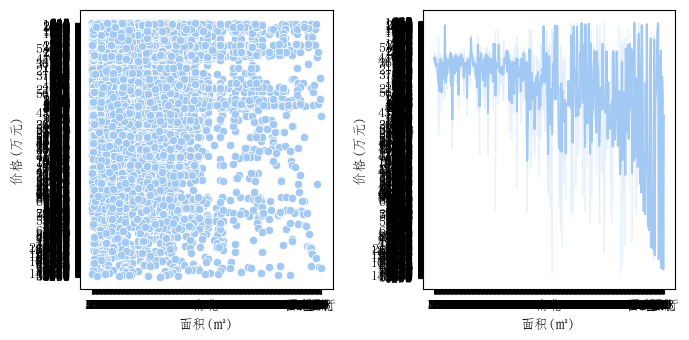

In [57]:
# 1. 按X轴列降序排序（ascending=False=从大到小）
df_sorted = df.sort_values(by='你的X轴列名', ascending=False)

# 2. 用排序后的数据绘图，X轴自动从大到小
df_sorted.plot(x='你的X轴列名', y='你的Y轴列名')
fig, axes = plt.subplots(1, 2)
sns.scatterplot(data=clean_data, x='面积(㎡)', y='价格(万元)', ax=axes[0])
sns.lineplot(data=clean_data, x='面积(㎡)', y='价格(万元)', ax=axes[1])
plt.show()

In [55]:
sns.set_palette('pastel')
# 核心两行：设置仿宋字体 + 解决负号显示问题
plt.rcParams['font.sans-serif'] = ['FangSong']  # 仿宋的英文名称是FangSong
plt.rcParams['axes.unicode_minus'] = False